# 3 · Preprocesamiento y modelado con PySpark (seis modelos)

**Objetivo del capítulo.** Lo mismo que en el capítulo de scikit-learn, pero con **Spark MLlib**:
lectura del CSV completo, las mismas variables, la **misma partición** entrenamiento/prueba **y los mismos
pliegues**, los **seis modelos** (`LogisticRegression`, `DecisionTreeClassifier`,
`RandomForestClassifier`, `GBTClassifier`, `LinearSVC`, `NaiveBayes`) con `ParamGridBuilder` +
`CrossValidator` (`numFolds = 3`), medición de tiempos y LIME sobre el mejor modelo con probabilidades.

## Protocolo experimental en PySpark

| Elemento | Dónde |
|---|---|
| Conjunto de datos **completo**, sin muestreo | 3.2 (se lee el CSV entero) |
| Ninguna transferencia de datos al *driver* antes de entrenar | Ninguna celda lo hace antes del ajuste. Las únicas transferencias al driver son **agregados diminutos** (conteos por categoría, sumas de aciertos para el umbral) y, **después de entrenar**, `id`, `default` y la puntuación del conjunto de prueba (3 columnas) para DeLong y las curvas ROC |
| `StringIndexer` + `OneHotEncoder` + `VectorAssembler` | 3.4 |
| **Cachear** el DataFrame tras el `VectorAssembler` y antes del modelo (`persist(MEMORY_AND_DISK)`) | 3.4 |
| Hiperparámetros **solo** con `ParamGridBuilder` + `CrossValidator` (`numFolds = 3`, `foldCol` con los mismos pliegues que scikit-learn), sin bucles manuales | 3.5 |
| Evaluar con `BinaryClassificationEvaluator`; exactitud, precisión, sensibilidad, F1, ROC AUC y matriz de confusión (manual) | 3.5 y 3.6 |
| Tiempo total de entrenamiento y predicción de **cada modelo** (incluye la validación cruzada); la transferencia de `id`, `default` y puntuación se mide aparte | 3.5 |
| Configuración de la sesión (paralelismo y memoria) | 3.1 |

```{note}
La partición 80/20 **no** usa `randomSplit`: se lee el mismo archivo (`id`, `split`, `fold`) que el capítulo de
scikit-learn (hecho en el EDA, estratificado), de modo que ambos motores ven exactamente los mismos
préstamos. `randomSplit` solo aparece en la sección 3.3, en una celda de demostración que muestra por qué
no serviría para este fin; **no interviene en la partición real ni en el entrenamiento de los modelos**.
```

In [1]:
import gc
import json
import os
import platform
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sys.path.insert(0, str(Path.cwd().parent))
from src import lc_models as lm  # noqa: E402
from src import lc_spark_models as lsm  # noqa: E402
from src import lc_utils as lc  # noqa: E402

# Spark 3.5 necesita Java 8/11/17 (no funciona con Java 25). Se usa el JDK 17 del entorno conda.
if "JAVA_HOME" not in os.environ:
    jvm = Path(sys.prefix) / "Library" / "lib" / "jvm"
    if jvm.exists():
        os.environ["JAVA_HOME"] = str(jvm)
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

import pyspark  # noqa: E402
from pyspark import StorageLevel  # noqa: E402
from pyspark.ml import Pipeline  # noqa: E402
from pyspark.ml.feature import OneHotEncoder, StandardScaler, StringIndexer, VectorAssembler  # noqa: E402
from pyspark.ml.functions import vector_to_array  # noqa: E402
from pyspark.sql import SparkSession  # noqa: E402
from pyspark.sql import functions as F  # noqa: E402

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold"})
RESULTS, DATA_DIR = Path("../resultados"), Path("../data")
TIMES = {}
ESTADO = {}


def guardar_estado():
    """Escribe a disco lo calculado hasta ahora (si una etapa posterior fallara, no se pierde lo anterior)."""
    (RESULTS / "sp_resultados.json").write_text(
        json.dumps({**ESTADO, "tiempos_s": TIMES}, indent=2, default=float), encoding="utf-8")


print(f"Python {platform.python_version()} · PySpark {pyspark.__version__}")

Python 3.10.21 · PySpark 3.5.9


## 3.1 Configuración de la sesión

La sesión fija paralelismo y memoria de forma explícita, más dos líneas que **no** cambian esa
configuración: `spark.ui.showConsoleProgress` (apaga la barra de progreso para que la salida sea legible) y
`spark.sql.execution.arrow.pyspark.enabled = true` (transferencia en bloques entre Python y la JVM). La
segunda **no era opcional en la práctica**: en una ejecución preliminar de este trabajo, sin Arrow, cada
llamada de predicción desde Python tardó ≈ 7–8 minutos (se mide en el capítulo 3b).

In [2]:
t0 = time.time()
spark = (SparkSession.builder
         .appName("LendingClub_Optimized")
         .config("spark.sql.shuffle.partitions", "400")
         .config("spark.default.parallelism", "400")
         .config("spark.executor.memory", "8g")
         .config("spark.driver.memory", "8g")
         .config("spark.memory.fraction", 0.8)
         .config("spark.memory.storageFraction", 0.3)
         .config("spark.ui.showConsoleProgress", "false")
         .config("spark.sql.execution.arrow.pyspark.enabled", "true")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
TIMES["arranque_sesion"] = time.time() - t0
conf = dict(spark.sparkContext.getConf().getAll())
heap = spark._jvm.java.lang.Runtime.getRuntime().maxMemory() / 1e9
print(f"Spark {spark.version} · master = {spark.sparkContext.master} · arranque {TIMES['arranque_sesion']:.1f} s")
print(f"defaultParallelism (fijado a mano, no son los núcleos reales): {spark.sparkContext.defaultParallelism}")
for k in ("spark.sql.shuffle.partitions", "spark.default.parallelism", "spark.executor.memory",
          "spark.driver.memory", "spark.memory.fraction", "spark.memory.storageFraction",
          "spark.sql.execution.arrow.pyspark.enabled"):
    print(f"  {k:32s} = {conf.get(k)}")
print(f"Memoria máxima de la JVM (heap): {heap:.1f} GB")

Spark 3.5.9 · master = local[*] · arranque 24.1 s
defaultParallelism (fijado a mano, no son los núcleos reales): 400
  spark.sql.shuffle.partitions     = 400
  spark.default.parallelism        = 400
  spark.executor.memory            = 8g
  spark.driver.memory              = 8g
  spark.memory.fraction            = 0.8
  spark.memory.storageFraction     = 0.3
  spark.sql.execution.arrow.pyspark.enabled = true
Memoria máxima de la JVM (heap): 8.6 GB


**Aclaración sobre el `defaultParallelism` de 400.** Este valor se debe a que
la sesión fija `spark.default.parallelism = 400` explícitamente; **no** son los núcleos reales. El equipo tiene
12 hilos lógicos (8 núcleos físicos). El valor 400 corresponde a una configuración pensada para un clúster con
muchos ejecutores; en el equipo utilizado equivale a más de 30 particiones por hilo, bastante más de lo que suele
convenir en una sola máquina, y su costo se mide en el capítulo 3b.

La ejecución se hace en **modo local** (`master = local[*]`): el *driver* y
los *executors* viven en **el mismo proceso** de la JVM. Por eso `spark.executor.memory = 8g` **no
tiene efecto** (no hay executors separados), y lo que limita la memoria es `spark.driver.memory`
(8 GB, verificado arriba en el *heap* real). En un clúster, ambos parámetros sí serían
independientes. Asimismo, `shuffle.partitions = 400` está pensado para un clúster: con 12 hilos
genera muchas tareas muy pequeñas. Su efecto real se mide en el capítulo 3b.

## 3.2 Lectura del CSV completo

`spark.read.csv` es **perezoso**: no lee nada hasta que se ejecuta una acción. Para medir el
tiempo de carga se fuerza la lectura con una acción que **no** transfiere datos al driver
(`format("noop")` procesa todas las filas y descarta el resultado).

In [3]:
CSV = str(lc.DATA_PATH)
# escape='"': en CSV, una comilla dentro de un texto entrecomillado se escribe duplicada (""). Sin esta
# opción Spark lee mal alguna fila (aquí: una fila menos entre los préstamos con desenlace conocido).
raw = spark.read.csv(CSV, header=True, inferSchema=False, escape='"')       # dataset COMPLETO
t0 = time.time()
raw.write.format("noop").mode("overwrite").save()                 # fuerza la lectura de las 151 columnas
TIMES["carga_csv_151_columnas"] = time.time() - t0
t0 = time.time()
n_total = raw.select(*lc.RAW_COLUMNS).count()                     # solo las 24 columnas necesarias
TIMES["carga_csv_24_columnas"] = time.time() - t0
print(f"Filas del archivo: {n_total:,} · columnas: {len(raw.columns)}")
print(f"Lectura completa (151 columnas, formato noop): {TIMES['carga_csv_151_columnas']:.1f} s")
print(f"Lectura de las 24 columnas necesarias + conteo:  {TIMES['carga_csv_24_columnas']:.1f} s")

Filas del archivo: 2,260,701 · columnas: 151
Lectura completa (151 columnas, formato noop): 8.0 s
Lectura de las 24 columnas necesarias + conteo:  3.8 s


**Comparabilidad de los tiempos de carga.** Estos tiempos no son comparables directamente con los de
pandas. Spark lee de forma **perezosa** y **descarta las columnas que ninguna operación necesita**
(*column pruning*): ni el `noop` ni el conteo requieren el valor de ninguna columna, así que Spark solo
recorre el archivo separando líneas (4–8 s). pandas, en cambio, **convierte a memoria las 151 columnas**
(más de un minuto; capítulo 1). El costo real de leer y convertir las columnas necesarias en Spark aparece
más abajo, dentro del **preprocesamiento** (sección 3.4: 323 s, que incluye leer, construir variables,
unir con la partición, ajustar los transformadores y cachear). En la sección 6.3 la comparación de
"carga" se hace con ese tiempo total en ambos lados.

## 3.3 Variables y partición (idénticas a las de scikit-learn)

Las variables se calculan con las **mismas reglas** que en pandas (`src/lc_utils.py`), escritas con
funciones de Spark. Luego se une con el archivo de la partición hecho en el EDA (`id`, `split`, `fold`).

**¿Por qué no `randomSplit`?** (1) No es **estratificado**; (2) su resultado depende del número de
particiones del DataFrame (no es reproducible si cambia el particionado; se demuestra abajo); y
(3) daría un conjunto de prueba **distinto** al de scikit-learn, impidiendo comparar ambos modelos sobre los mismos
préstamos. Unir con una lista fija de `id` es una transformación de Spark (no mueve datos al driver).

In [4]:
MONTHS_MAP = F.create_map([F.lit(x) for kv in lc.MONTHS.items() for x in kv])


def year_month(col):
    """'Aug-2003' -> 2003 + 7/12; misma regla que en pandas (independiente del idioma del sistema)."""
    return F.substring(col, -4, 4).cast("double") + (MONTHS_MAP[F.substring(col, 1, 3)].cast("double") - 1) / 12.0


NUM_RAW = ["loan_amnt", "int_rate", "installment", "annual_inc", "dti", "fico_range_high", "open_acc",
           "revol_bal", "revol_util", "total_acc", "pub_rec", "delinq_2yrs", "inq_last_6mths", "mort_acc"]


def build_features(sdf):
    d = sdf.filter(F.col("loan_status").isin(lc.RESOLVED))          # desenlace conocido (no es muestreo)
    return d.select(
        F.col("id").cast("string").alias("id"),
        (F.col("loan_status") == "Charged Off").cast("int").alias("default"),
        F.substring("issue_d", -4, 4).cast("int").alias("issue_year"),
        F.regexp_extract("term", r"(\d+)", 1).cast("double").alias("term_months"),
        F.when(F.col("emp_length").isNull(), F.lit(None).cast("double"))
         .when(F.col("emp_length").startswith("<"), F.lit(0.0))
         .otherwise(F.regexp_extract("emp_length", r"(\d+)", 1).cast("double")).alias("emp_length"),
        (year_month(F.col("issue_d")) - year_month(F.col("earliest_cr_line"))).alias("credit_history_years"),
        *[F.col(c).cast("double").alias(c) for c in NUM_RAW],
        *[F.coalesce(F.col(c), F.lit("Desconocido")).alias(c) for c in lc.CATEGORICAL])


t_prep0 = time.time()
split_sdf = spark.read.parquet(str(DATA_DIR / "split_ids.parquet"))           # id, split, fold, is_test, rank
feat = build_features(raw).join(F.broadcast(split_sdf), on="id", how="inner")
n_modelo = feat.count()
print(f"Préstamos con desenlace conocido tras unir con la partición: {n_modelo:,} (esperado: {split_sdf.count():,})")
assert n_modelo == split_sdf.count(), "El join perdió o duplicó filas"

# Paridad con pandas: las medias de cada variable deben coincidir con las calculadas en el capítulo de sklearn.
par = RESULTS / "paridad_features.json"
if par.exists():
    ref = json.loads(par.read_text())
    med = feat.agg(*[F.mean(c).alias(c) for c in lc.NUMERIC]).first().asDict()
    dif = pd.Series({c: abs(med[c] - ref["medias"][c]) / max(abs(ref["medias"][c]), 1e-12) for c in lc.NUMERIC})
    print(f"Paridad pandas vs Spark (diferencia relativa máxima de las medias): {dif.max():.2e}")
    assert dif.max() < 1e-9, "Las features de Spark no coinciden con las de pandas"

Préstamos con desenlace conocido tras unir con la partición: 1,345,310 (esperado: 1,345,310)


Paridad pandas vs Spark (diferencia relativa máxima de las medias): 2.28e-15


In [5]:
# ¿Por qué no randomSplit? Misma semilla, distinto particionado -> particiones DISTINTAS.
base = feat.select("id")
test8 = base.repartition(8).randomSplit([0.8, 0.2], seed=42)[1]
test64 = base.repartition(64).randomSplit([0.8, 0.2], seed=42)[1]
n8, n64, comun = test8.count(), test64.count(), test8.join(test64, "id").count()     # solo conteos
print(f"randomSplit con la MISMA semilla y distinto particionado (8 vs 64): test de {n8:,} y {n64:,} filas; "
      f"solo {comun / n8:.1%} de las filas de prueba coinciden -> no es reproducible entre configuraciones.")

randomSplit con la MISMA semilla y distinto particionado (8 vs 64): test de 268,696 y 269,605 filas; solo 20.0% de las filas de prueba coinciden -> no es reproducible entre configuraciones.


`test8` y `test64` son objetos desechables de esta demostración: no se usan en ninguna celda posterior.
La partición real de entrenamiento y prueba, la que sí alimenta los seis modelos, es la unión por `id`
hecha arriba (3.3) con el archivo compartido con scikit-learn; `randomSplit` no interviene en el modelado.

## 3.4 Preprocesamiento: `StringIndexer` + `OneHotEncoder` + `VectorAssembler` + caché

* **Categorías infrecuentes:** las que tengan **< 1 % del entrenamiento** se agrupan en
  `infrecuente` (igual que `OneHotEncoder(min_frequency=0.01)` de scikit-learn). Para calcularlas
  solo se traen al driver los **conteos por categoría** (≤ 51 filas por variable): un agregado
  mínimo, no el conjunto de datos.
* **Nulos numéricos:** centinela −1 (sin parámetros aprendidos), igual que en scikit-learn.
* **Escalado** (`StandardScaler`, media 0 y desviación 1) en la columna `features_sc`, que usan solo la
  regresión logística y la SVM lineal; los árboles, el *boosting* y Naive Bayes usan `features` (sin escalar).
  Se ajusta **solo con el entrenamiento** (como en scikit-learn).
* Los transformadores se **ajustan solo con el entrenamiento** y luego se aplican al conjunto de prueba.
* **Se cachea** el DataFrame resultante con `persist(MEMORY_AND_DISK)`, **después** del
  `VectorAssembler` y **antes** de cualquier modelo.

In [6]:
train_raw = feat.filter(F.col("split") == "train")
n_train = train_raw.count()
keep, n_raras = {}, {}
for c in lc.CATEGORICAL:
    conteos = train_raw.groupBy(c).count().collect()                # <= 51 filas: agregado diminuto
    keep[c] = sorted(r[c] for r in conteos if r["count"] >= 0.01 * n_train)
    n_raras[c] = len(conteos) - len(keep[c])
infrec = RESULTS / "categorias_infrecuentes.json"
if infrec.exists():
    ref = json.loads(infrec.read_text())
    for c in lc.CATEGORICAL:
        raras = sorted(r[c] for r in train_raw.groupBy(c).count().collect() if r["count"] < 0.01 * n_train)
        assert raras == ref[c], f"Categorías infrecuentes de {c} distintas a las de scikit-learn"
    print("Categorías infrecuentes idénticas a las de scikit-learn: OK")
print({c: len(v) for c, v in keep.items()}, "categorías frecuentes por variable")


def to_model_input(sdf):
    """Aplica las reglas de preprocesamiento sin parámetros aprendidos (mapeo de raras + centinela)."""
    out = sdf.na.fill(-1.0, subset=lc.NUMERIC)
    for c in lc.CATEGORICAL:
        out = out.withColumn(c, F.when(F.col(c).isin(keep[c]), F.col(c)).otherwise(F.lit("infrecuente")))
    return out


idx_out = [f"{c}_idx" for c in lc.CATEGORICAL]
ohe_out = [f"{c}_ohe" for c in lc.CATEGORICAL]
prep_stages = [StringIndexer(inputCols=lc.CATEGORICAL, outputCols=idx_out, handleInvalid="keep"),
               OneHotEncoder(inputCols=idx_out, outputCols=ohe_out, dropLast=False, handleInvalid="keep"),
               VectorAssembler(inputCols=lc.NUMERIC + ohe_out, outputCol="features", handleInvalid="keep"),
               StandardScaler(inputCol="features", outputCol="features_sc", withMean=True, withStd=True)]

train_in = to_model_input(train_raw)
test_in = to_model_input(feat.filter(F.col("split") == "test"))
prep_model = Pipeline(stages=prep_stages).fit(train_in)             # se ajusta SOLO con el entrenamiento
cols_keep = ["id", "default", "issue_year", "term_months", "rank", F.col("fold").cast("int").alias("fold"), "features", "features_sc"]
train_f = prep_model.transform(train_in).select(*cols_keep).persist(StorageLevel.MEMORY_AND_DISK)
test_f = prep_model.transform(test_in).select(*cols_keep).persist(StorageLevel.MEMORY_AND_DISK)
n_train_f, n_test_f = train_f.count(), test_f.count()               # materializa la caché
TIMES["preprocesamiento"] = time.time() - t_prep0
n_feat = len(train_f.select("features").first()[0])
n_equiv = len(lc.NUMERIC) + sum(len(keep[c]) + (1 if n_raras[c] > 0 else 0) for c in lc.CATEGORICAL)
print(f"train = {n_train_f:,} · test = {n_test_f:,} · preprocesamiento + caché en {TIMES['preprocesamiento']:.0f} s")
print(f"Dimensión del vector de features: {n_feat} (= {n_equiv} equivalentes a scikit-learn + "
      f"{n_feat - n_equiv} columnas 'categoría desconocida' que Spark añade con handleInvalid='keep' y quedan siempre en 0)")
print("Nivel de almacenamiento:", train_f.storageLevel)

Categorías infrecuentes idénticas a las de scikit-learn: OK
{'purpose': 8, 'home_ownership': 3, 'addr_state': 28, 'verification_status': 3} categorías frecuentes por variable


train = 1,076,248 · test = 269,062 · preprocesamiento + caché en 323 s
Dimensión del vector de features: 70 (= 62 equivalentes a scikit-learn + 8 columnas 'categoría desconocida' que Spark añade con handleInvalid='keep' y quedan siempre en 0)
Nivel de almacenamiento: Disk Memory Serialized 1x Replicated


## 3.5 Los seis modelos y sus espacios de búsqueda

**Los mismos** que en scikit-learn (`src/lc_models.py` define los espacios una sola vez). El efecto de
`maxBins` se analiza en la Discusión (diferencias de implementación).

| Modelo | Estimador de PySpark | Espacio de búsqueda | Datos |
|---|---|---|---|
| Regresión logística | `LogisticRegression(elasticNetParam=0)` (L2) | `regParam` ∈ {1e-6, 1e-5, 1e-4} | escalados |
| Árbol de decisión | `DecisionTreeClassifier` (`maxBins=32`) | `maxDepth` ∈ {5, 10, 15} | sin escalar |
| Bosque aleatorio | `RandomForestClassifier` (`maxBins=32`) | `numTrees` ∈ {10, 50, 100} × `maxDepth` ∈ {5, 10, 15} | sin escalar |
| Gradient boosting | `GBTClassifier(stepSize=0.1)` (`maxBins=32`) | `maxIter` ∈ {50, 100} × `maxDepth` ∈ {3, 5} | sin escalar |
| SVM lineal | `LinearSVC` (pérdida *hinge*, L2) | `regParam` ∈ {1e-6, 1e-5, 1e-4} | escalados |
| Naive Bayes | `NaiveBayes(modelType="gaussian")` | sin búsqueda (una combinación) | sin escalar |

## 3.6 Entrenamiento con `ParamGridBuilder` + `CrossValidator`

Para **cada** modelo (función `lsm.run_model`):

1. `CrossValidator(numFolds=3, foldCol="fold", parallelism=1)` con `BinaryClassificationEvaluator`
   (`areaUnderROC`), que también es el criterio de selección. `foldCol` hace que Spark use **los mismos
   3 pliegues estratificados** que scikit-learn (en vez de pliegues al azar sin estratificar). El tiempo incluye la validación cruzada y el
   reajuste final del mejor modelo con todo el entrenamiento.
2. Predicción sobre el conjunto de prueba con pocas tareas simultáneas (`coalesce`): cada tarea recibe
   una copia del modelo y, con un bosque grande, el *heap* de 8 GB no alcanza si se ejecutan unas 12 a la vez.
3. **Transferencia al driver, después de entrenar y predecir,** solo de `id`, `default` y la puntuación
   del conjunto de prueba (`probability[1]`, o `rawPrediction[1]` en `LinearSVC`); su tiempo se mide **aparte**.
4. Umbral de decisión con puntuaciones **fuera de pliegue** del entrenamiento: se reajusta el mejor
   modelo dejando fuera cada pliegue (bucle sobre **pliegues**, no sobre hiperparámetros) y los aciertos
   para una malla de umbrales se calculan con **agregados de Spark** (no se trae ninguna fila).

```{note}
El `BinaryClassificationEvaluator` usa `probability` (no `rawPrediction`) en los modelos que la tienen:
en `DecisionTreeClassifier` la columna `rawPrediction` contiene **conteos** de la hoja, cuyo orden no es el
de la probabilidad; `LinearSVC` no produce probabilidades, así que se evalúa con `rawPrediction`
(el margen de decisión).
```

**Ajustes por restricciones de memoria.** Con 16 GB de RAM el bosque de 100 árboles y profundidad 15 agotó la memoria en
varios intentos (`OutOfMemoryError`) mientras se tuvo `parallelism = 3` y `maxMemoryInMB = 256`. La traza
mostró que se agotaban los buffers de **histogramas** de los niveles profundos. Las decisiones que lo
resolvieron y no cambian el algoritmo: `parallelism = 1` (un modelo a la vez), `maxMemoryInMB = 64` (límite
de memoria de histogramas por pasada; documentado en el modelo) y predicción con pocas tareas simultáneas.

In [7]:
MODELOS = {}
BEST_PROB = {"clave": None, "auc": -1.0, "modelo": None}         # solo se conserva en memoria el mejor con probabilidades
t_total0 = time.time()
for clave in lm.CLAVES:
    r, mdl = lsm.run_model(spark, clave, train_f, test_f, RESULTS, keep_model=(clave != "SVM"))
    MODELOS[clave] = r
    if mdl is not None and r["auc_test"] > BEST_PROB["auc"]:
        BEST_PROB.update(clave=clave, auc=r["auc_test"], modelo=mdl)
    del mdl
    gc.collect()
    spark._jvm.System.gc()
TIMES["seis_modelos_esta_sesion_s"] = time.time() - t_total0

[LR] mejores {'regParam': 1e-06} · AUC CV 0.7096 · entrenamiento+CV 3799 s


[LR] AUC test 0.7095 · predicción 0.8 s · transferencia 0.5 s · umbral OOF 0.206 (365 s)


[DT] mejores {'maxDepth': 10} · AUC CV 0.7002 · entrenamiento+CV 3867 s


[DT] AUC test 0.7004 · predicción 0.6 s · transferencia 0.3 s · umbral OOF 0.206 (334 s)


[RF] mejores {'maxDepth': 15, 'numTrees': 100} · AUC CV 0.7152 · entrenamiento+CV 21145 s


...

[GB] AUC test 0.7189 · predicción 2.4 s · transferencia 0.5 s · umbral OOF 0.216 (12059 s)


[SVM] mejores {'regParam': 1e-05} · AUC CV 0.6113 · entrenamiento+CV 12955 s


[SVM] AUC test 0.5985 · predicción 0.6 s · transferencia 0.3 s · umbral OOF -1.000 (3478 s)


[NB] mejores {} · AUC CV 0.6887 · entrenamiento+CV 2562 s


[NB] AUC test 0.6883 · predicción 0.6 s · transferencia 0.3 s · umbral OOF 0.216 (19 s)


## 3.7 Resumen de la validación cruzada y de los tiempos

,mejores hiperparámetros,maxBins,AUC CV,± sd (pliegues),AUC test,entrenamiento + CV (s),predicción test (s),transferencia al driver (s),umbral OOF (s)
modelo,,,,,,,,,
Regresión logística,"{""regParam"": 1e-06}",nan,0.7096,0.0002,0.7095,"3,799",0.8,0.5,365
Árbol de decisión,"{""maxDepth"": 10}",32.000000,0.7002,0.0005,0.7004,"3,867",0.6,0.3,334
Bosque aleatorio,"{""maxDepth"": 15, ""numTrees"": 100}",32.000000,0.7152,0.0002,0.7152,"21,145",39.3,7.9,"6,730"
Gradient boosting,"{""maxDepth"": 5, ""maxIter"": 100}",32.000000,0.7182,0.0001,0.7189,"36,419",2.4,0.5,"12,059"
SVM lineal,"{""regParam"": 1e-05}",nan,0.6113,0.0021,0.5985,"12,955",0.6,0.3,"3,478"
Naive Bayes,{},nan,0.6887,0.0007,0.6883,"2,562",0.6,0.3,19


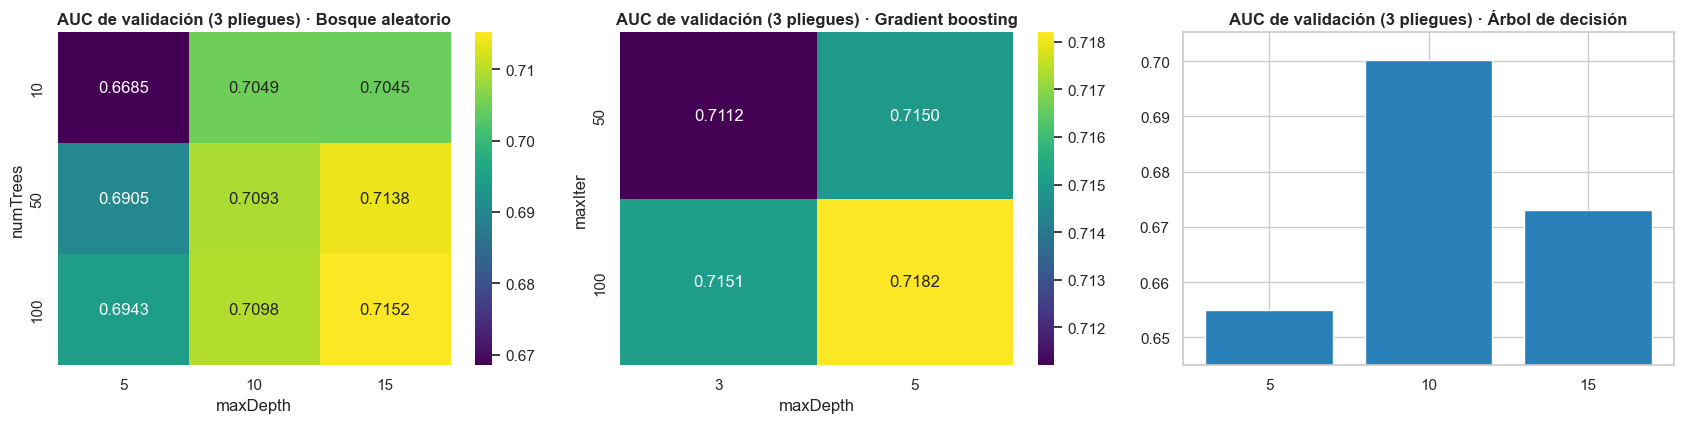

In [8]:
resumen = pd.DataFrame([{
    "modelo": r["modelo"], "mejores hiperparámetros": json.dumps(r["mejores_hiperparametros"]), "maxBins": r["maxBins"],
    "AUC CV": r["auc_cv"], "± sd (pliegues)": r["auc_cv_sd"], "AUC test": r["auc_test"],
    "entrenamiento + CV (s)": r["t_entrenamiento_con_cv_s"], "predicción test (s)": r["t_prediccion_s"],
    "transferencia al driver (s)": r["t_transferencia_s"], "umbral OOF (s)": r["t_oof_umbral_s"]}
    for r in MODELOS.values()]).set_index("modelo")
display(resumen.style.format({"AUC CV": "{:.4f}", "± sd (pliegues)": "{:.4f}", "AUC test": "{:.4f}", "entrenamiento + CV (s)": "{:,.0f}",
                              "predicción test (s)": "{:.1f}", "transferencia al driver (s)": "{:.1f}", "umbral OOF (s)": "{:,.0f}"}))
resumen.to_csv(RESULTS / "sp_resumen_modelos.csv")

fig, ax = plt.subplots(1, 3, figsize=(17, 4.4))
for a, clave in zip(ax, ["RF", "GB", "DT"]):
    cv_ = pd.read_csv(RESULTS / f"sp_cv_{clave}.csv")
    pcols = [c for c in cv_.columns if c != "mean_test_score"]
    if len(pcols) == 2:
        sns.heatmap(cv_.pivot(index=pcols[0], columns=pcols[1], values="mean_test_score"), annot=True, fmt=".4f", cmap="viridis", ax=a)
    else:
        a.bar(cv_[pcols[0]].astype(str), cv_["mean_test_score"], color="#2980b9")
        a.set_ylim(cv_["mean_test_score"].min() - 0.01, cv_["mean_test_score"].max() + 0.005)
    a.set_title(f"AUC de validación (3 pliegues) · {lm.NOMBRES[clave]}")
plt.tight_layout()
plt.show()

## 3.8 Evaluación en el conjunto de prueba

Se reportan **exactitud, precisión, sensibilidad, F1 y ROC AUC**, junto con la matriz de confusión, con el umbral por
defecto (0.5; 0 para el valor de decisión de `LinearSVC`) y con el umbral elegido en el entrenamiento
(fuera de pliegue). El cálculo usa las tres columnas transferidas (`id`, `default`, puntuación).

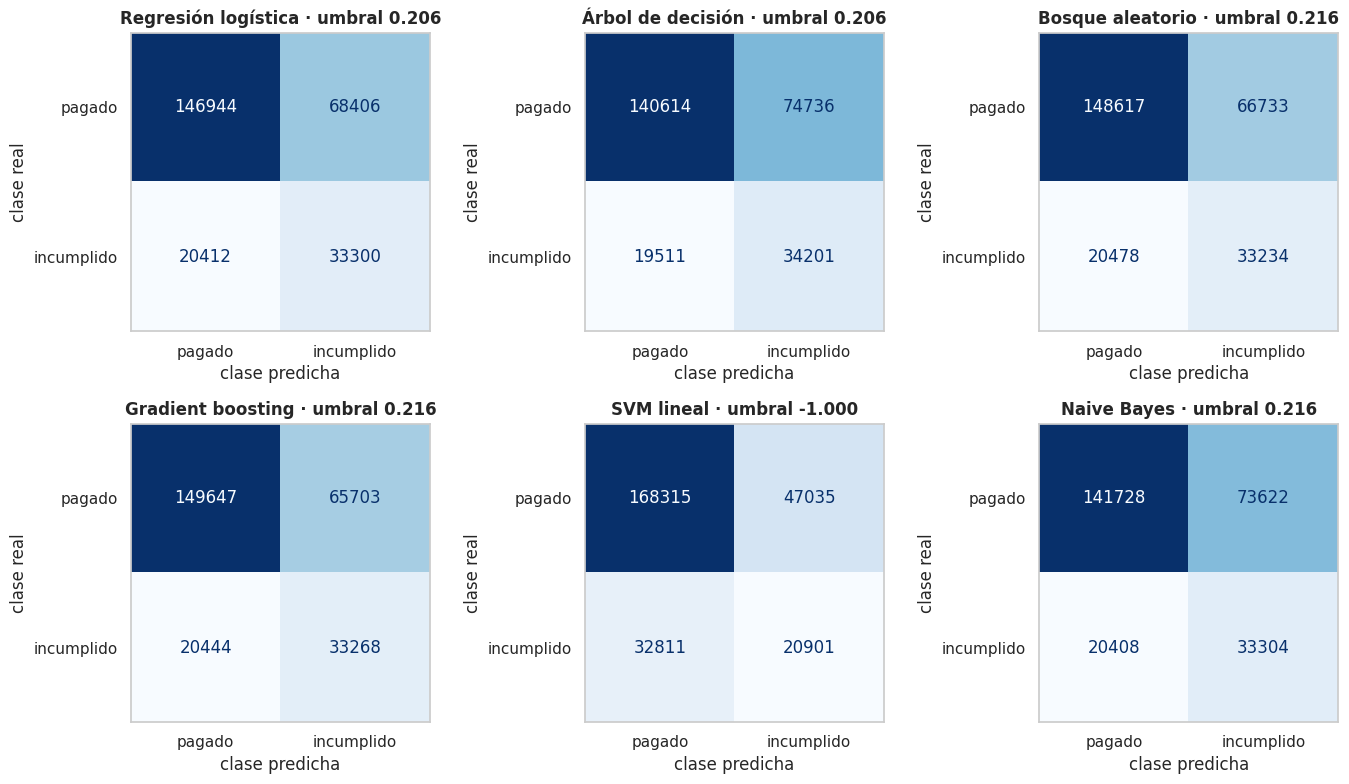

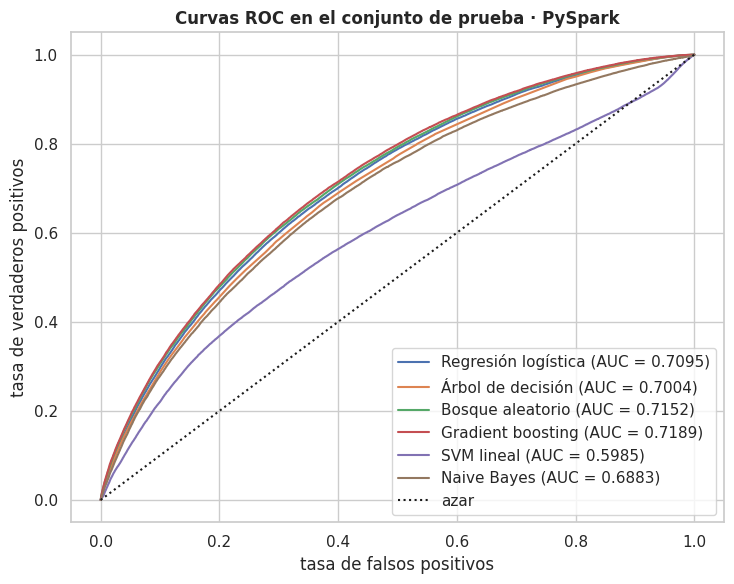

In [2]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, average_precision_score, roc_auc_score  # noqa: E402

from sklearn.metrics import roc_curve  # noqa: E402

SC = {k: pd.read_parquet(RESULTS / f"sp_scores_test_{k}.parquet") for k in lm.CLAVES}
if "MODELOS" not in globals():          # permite ejecutar esta celda sola, desde los resultados guardados
    MODELOS = {k: json.loads((RESULTS / f"sp_modelo_{k}.json").read_text(encoding="utf-8")) for k in lm.CLAVES}
for clave, r in MODELOS.items():
    r.setdefault("modelo", lm.NOMBRES[clave])
    r.setdefault("umbral_defecto", 0.0 if clave == "SVM" else 0.5)
filas = []
for clave, r in MODELOS.items():
    s = SC[clave]
    for nombre, thr in (("defecto", r["umbral_defecto"]), ("umbral F1 (OOF)", r["umbral_f1"])):
        mt = lc.threshold_metrics(s["y"].to_numpy(), s["score"].to_numpy(), thr)
        filas.append({"modelo": r["modelo"], "umbral usado": nombre, **mt, "ROC AUC": roc_auc_score(s["y"], s["score"]),
                      "AUC-PR": average_precision_score(s["y"], s["score"])})
met = pd.DataFrame(filas).set_index(["modelo", "umbral usado"])
fmt = {c: "{:.4f}" for c in ["accuracy", "precision", "recall", "f1", "ROC AUC", "AUC-PR"]}
fmt.update({"umbral": "{:.3f}", "TN": "{:,.0f}", "FP": "{:,.0f}", "FN": "{:,.0f}", "TP": "{:,.0f}"})
display(met[["umbral", "accuracy", "precision", "recall", "f1", "ROC AUC", "AUC-PR", "TN", "FP", "FN", "TP"]].style.format(fmt))
met.to_csv(RESULTS / "sp_metricas_test.csv")

fig, ax = plt.subplots(2, 3, figsize=(14, 8))
for a, (clave, r) in zip(ax.ravel(), MODELOS.items()):
    s = SC[clave]
    ConfusionMatrixDisplay.from_predictions(s["y"], (s["score"] >= r["umbral_f1"]).astype(int), display_labels=["pagado", "incumplido"],
                                            cmap="Blues", ax=a, colorbar=False, values_format="d")
    a.set(xlabel="clase predicha", ylabel="clase real")
    a.set_title(f"{r['modelo']} · umbral {r['umbral_f1']:.3f}")
    a.grid(False)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 6))
for clave, r in MODELOS.items():
    s = SC[clave]
    fpr, tpr, _ = roc_curve(s["y"], s["score"])
    ax.plot(fpr, tpr, label=f"{r['modelo']} (AUC = {roc_auc_score(s['y'], s['score']):.4f})")
ax.plot([0, 1], [0, 1], "k:", label="azar")
ax.set(xlabel="tasa de falsos positivos", ylabel="tasa de verdaderos positivos")
ax.legend(loc="lower right")
ax.set_title("Curvas ROC en el conjunto de prueba · PySpark")
plt.tight_layout()
plt.show()

## 3.9 LIME con el mejor modelo de PySpark que entrega probabilidades

LIME se aplica al modelo de mayor AUC de cada entorno entre los que entregan probabilidades
(`LinearSVC` no las produce), sobre dos préstamos mal clasificados por ambos entornos. Aquí se
hace con el modelo de Spark **tal como quedó tras la validación cruzada**, dentro de la misma sesión
(en Windows, Spark requiere `winutils` para escribir modelos en disco, así que LIME se ejecuta en la
misma sesión del entrenamiento). Los dos préstamos se eligieron entre los que
fallan en ambos entornos (uno que incumplió y ambos modelos dejaron pasar; uno que se pagó y ambos
marcaron como riesgoso), para poder comparar las explicaciones de scikit-learn (capítulo 4) y de PySpark.

Solo se traen al driver **una fila** (la instancia) y **20 000 filas de entrenamiento** al azar que LIME
necesita como referencia estadística; esas filas **no** entrenan nada y se traen **después** de entrenar.

In [10]:
sk_meta = json.loads((RESULTS / "sk_resultados.json").read_text())
clave_sk = sk_meta["lime_modelo"]
prob_sp = {k: r["auc_test"] for k, r in MODELOS.items() if r["score_col"] == "probability"}
clave_sp = max(prob_sp, key=prob_sp.get)
print(f"scikit-learn: {lm.NOMBRES[clave_sk]} (AUC {sk_meta['modelos'][clave_sk]['auc_test']:.4f}) · "
      f"PySpark: {lm.NOMBRES[clave_sp]} (AUC {prob_sp[clave_sp]:.4f})")
thr_sk, thr_sp = sk_meta["modelos"][clave_sk]["umbral_f1"], MODELOS[clave_sp]["umbral_f1"]
d = (pd.read_parquet(RESULTS / "sk_scores_test.parquet")[["id", "y", clave_sk]].rename(columns={clave_sk: "p_sklearn"})
     .merge(SC[clave_sp][["id", "score"]].rename(columns={"score": "p_spark"}), on="id"))
d["pct"] = d["p_sklearn"].rank(pct=True) + d["p_spark"].rank(pct=True)          # percentil conjunto de riesgo
fn = d[(d["y"] == 1) & (d["p_sklearn"] < thr_sk) & (d["p_spark"] < thr_sp)].nsmallest(1, "pct").iloc[0]
fp = d[(d["y"] == 0) & (d["p_sklearn"] >= thr_sk) & (d["p_spark"] >= thr_sp)].nlargest(1, "pct").iloc[0]
inst = {"FN": {"id": str(fn["id"]), "p_sklearn": float(fn["p_sklearn"]), "p_spark": float(fn["p_spark"])},
        "FP": {"id": str(fp["id"]), "p_sklearn": float(fp["p_sklearn"]), "p_spark": float(fp["p_spark"])},
        "modelo_sklearn": clave_sk, "modelo_spark": clave_sp, "umbral_sklearn": thr_sk, "umbral_spark": thr_sp}
(RESULTS / "instancias_lime.json").write_text(json.dumps(inst, indent=1), encoding="utf-8")
print(json.dumps(inst, indent=1))

scikit-learn: Gradient boosting (AUC 0.7196) · PySpark: Gradient boosting (AUC 0.7189)


{
 "FN": {
  "id": "36099806",
  "p_sklearn": 0.02005936721168558,
  "p_spark": 0.02212184328392397
 },
 "FP": {
  "id": "55961482",
  "p_sklearn": 0.8256249625310915,
  "p_spark": 0.8630584017737063
 },
 "modelo_sklearn": "GB",
 "modelo_spark": "GB",
 "umbral_sklearn": 0.22363636363636363,
 "umbral_spark": 0.2159
}


In [11]:
modelo_lime = BEST_PROB["modelo"] if BEST_PROB["clave"] == clave_sp else None
if modelo_lime is None:                                  # tras una reanudación el objeto ya no está en memoria: se reajusta
    t0 = time.time()
    modelo_lime = lsm.refit_best(clave_sp, MODELOS[clave_sp], train_f)
    print(f"Modelo reajustado con sus mejores hiperparámetros en {time.time() - t0:.0f} s")
col_prob = "probability"
ref_lime = train_raw.select(*lc.FEATURES).sample(fraction=0.03, seed=lc.SEED).limit(20000).toPandas()     # referencia de LIME
filas_lime = {k: feat.filter(F.col("id") == inst[k]["id"]).select(*lc.FEATURES).toPandas() for k in ("FN", "FP")}
print(f"Referencia para LIME: {len(ref_lime):,} filas de entrenamiento · instancias: {[len(v) for v in filas_lime.values()]} fila(s)")


def predecir_spark(pdf: pd.DataFrame) -> np.ndarray:
    """DataFrame de variables crudas (pandas) -> probabilidad de incumplimiento, con el modelo de Spark."""
    s = spark.createDataFrame(pdf[lc.FEATURES]).coalesce(1)
    x = prep_model.transform(to_model_input(s))
    return np.array(lsm.pred_con(modelo_lime, x, n=1).select(vector_to_array(col_prob)[1]).toPandas().iloc[:, 0])


# Latencia real del modelo final (con Arrow) según el tamaño del lote
lote = feat.filter(F.col("split") == "test").select(*lc.FEATURES).limit(5000).toPandas()
lat = {}
for n in (1, 100, 5000):
    ts = []
    for _ in range(3):
        t0 = time.perf_counter()
        predecir_spark(lote.iloc[:n])
        ts.append(time.perf_counter() - t0)
    lat[n] = float(np.median(ts))
print("Latencia del modelo final de Spark (con Arrow):", {k: f"{v:.2f} s" for k, v in lat.items()})

Referencia para LIME: 20,000 filas de entrenamiento · instancias: [1, 1] fila(s)


Latencia del modelo final de Spark (con Arrow): {1: '0.29 s', 100: '0.27 s', 5000: '0.51 s'}


In [12]:
adapter = lc.LimeAdapter(ref_lime, predecir_spark, extra=pd.concat(filas_lime.values()))
LIME = {"modelo": clave_sp, "latencia_predict_s": {str(k): v for k, v in lat.items()}, "instancias": {}}
for k, f in filas_lime.items():
    t0 = time.time()
    e = adapter.explain(f, num_features=10, num_samples=5000)
    seg = time.time() - t0
    LIME["instancias"][k] = {"id": inst[k]["id"], "tiempo_s": seg, "r2_local": float(e.score),
                             "pred_local": float(e.local_pred[0]), "p_spark": float(predecir_spark(f)[0]),
                             "pesos": [[a_, float(b_)] for a_, b_ in e.as_list(label=1)]}
    print(f"\n=== {k} (préstamo {inst[k]['id']}) · {seg:.1f} s · R² local {e.score:.3f} · probabilidad de Spark "
          f"{LIME['instancias'][k]['p_spark']:.3f}")
    display(pd.DataFrame(e.as_list(label=1), columns=["condición de la variable", "peso (hacia 'incumple' si > 0)"]))
(RESULTS / "lime_spark.json").write_text(json.dumps(LIME, indent=1, default=float), encoding="utf-8")


=== FN (préstamo 36099806) · 0.6 s · R² local 0.510 · probabilidad de Spark 0.022


,condición de la variable,peso (hacia 'incumple' si > 0)
0,int_rate <= 9.17,-0.1222
1,term_months <= 36.00,-0.0859
2,fico_range_high > 714.00,-0.0460
3,dti <= 12.08,-0.0395
4,home_ownership=MORTGAGE,-0.0294
5,open_acc <= 8.00,-0.0239
6,inq_last_6mths <= 0.00,-0.0191
7,annual_inc > 90496.25,-0.0164
8,revol_bal > 19969.75,-0.0164
9,verification_status=Not Verified,-0.0148



=== FP (préstamo 55961482) · 0.6 s · R² local 0.554 · probabilidad de Spark 0.863


,condición de la variable,peso (hacia 'incumple' si > 0)
0,int_rate > 15.59,0.1297
1,term_months > 36.00,0.0943
2,fico_range_high > 714.00,-0.0428
3,dti <= 12.08,-0.0380
4,home_ownership=RENT,0.0280
5,loan_amnt > 20000.00,0.0252
6,mort_acc <= 0.00,0.0220
7,annual_inc > 90496.25,-0.0213
8,open_acc <= 8.00,-0.0212
9,total_acc <= 16.00,0.0207


1897

## 3.10 Guardar resultados

In [13]:
ESTADO.update({"spark_version": spark.version, "heap_jvm_gb": float(heap), "nucleos_defaultParallelism": int(spark.sparkContext.defaultParallelism),
               "hilos_reales": os.cpu_count(), "filas_train": int(n_train_f), "filas_test": int(n_test_f), "dimension_features": int(n_feat),
               "numFolds": 3, "maxMemoryInMB": lsm.MAXMEM, "maxBins": lsm.MAXBINS, "lime_modelo": clave_sp, "modelos": MODELOS})
guardar_estado()
print("Guardado:", sorted(p.name for p in RESULTS.glob("sp_*")))
spark.stop()

Guardado: ['sp_cv_DT.csv', 'sp_cv_GB.csv', 'sp_cv_LR.csv', 'sp_cv_NB.csv', 'sp_cv_RF.csv', 'sp_cv_SVM.csv', 'sp_metricas_test.csv', 'sp_modelo_DT.json', 'sp_modelo_GB.json', 'sp_modelo_LR.json', 'sp_modelo_NB.json', 'sp_modelo_RF.json', 'sp_modelo_SVM.json', 'sp_resultados.json', 'sp_resumen_modelos.csv', 'sp_scores_test_DT.parquet', 'sp_scores_test_GB.parquet', 'sp_scores_test_LR.parquet', 'sp_scores_test_NB.parquet', 'sp_scores_test_RF.parquet', 'sp_scores_test_SVM.parquet']
